# Part 03 - CLV Prediction Model Development & Evaluation

This notebook uses the customer-level dataset created in Part 02 to predict future customer value.

The models will be compared using MAE, RMSE, and R².

The first model will be a simple baseline, followed by Random Forest and XGBoost.

## 1. Load the Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

## 2. Load the Customer-Level CLV Dataset

Part 03 starts from the customer-level dataset created during Part 02.

In [2]:
file_path = "../data/processed/customer_clv_dataset.csv"

customer_data = pd.read_csv(
    file_path,
    parse_dates=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

customer_data.head()

,CustomerID,first_purchase_date,last_purchase_date,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity,Future_90d_Orders,Future_90d_Value
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27,0,0.00
1,12347,2010-10-31 14:20:00,2011-08-02 08:48:00,39,313,10.4,314,6,3402.39,567.065000,0.019108,107,2,1519.14
2,12348,2010-09-27 14:59:00,2011-04-05 10:47:00,158,347,11.6,348,4,1709.40,427.350000,0.011494,25,1,310.00
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,317,498,16.6,499,3,2671.14,890.380000,0.006012,90,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,219,219,7.3,220,1,334.40,334.400000,0.004545,17,0,0.00


### 2.1 Basic Dataset Check

In [3]:
customer_data.shape

(5281, 14)

In [4]:
customer_data.dtypes

CustomerID                      int64
first_purchase_date    datetime64[ns]
last_purchase_date     datetime64[ns]
Recency                         int64
Tenure_days                     int64
Tenure_months                 float64
active_days                     int64
Frequency                       int64
Monetary                      float64
AvgOrderValue                 float64
PurchaseFrequency             float64
ProductDiversity                int64
Future_90d_Orders               int64
Future_90d_Value              float64
dtype: object

In [5]:
customer_data.isnull().sum()

CustomerID             0
first_purchase_date    0
last_purchase_date     0
Recency                0
Tenure_days            0
Tenure_months          0
active_days            0
Frequency              0
Monetary               0
AvgOrderValue          0
PurchaseFrequency      0
ProductDiversity       0
Future_90d_Orders      0
Future_90d_Value       0
dtype: int64

In [6]:
customer_data["CustomerID"].nunique()

5281

In [7]:
customer_data["Future_90d_Value"].describe()

count      5281.000000
mean        575.905666
std        4019.926054
min           0.000000
25%           0.000000
50%           0.000000
75%         434.900000
max      168469.600000
Name: Future_90d_Value, dtype: float64

## 3. Define the Model Features and Target

The target is `Future_90d_Value`.

Customer ID, raw date fields, the target itself, and `Future_90d_Orders` will not be used as model features.

`Future_90d_Orders` is excluded because it comes from the same future period as the target and would introduce future information into the model.

In [8]:
feature_columns = [
    "Recency",
    "Tenure_days",
    "Tenure_months",
    "active_days",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "PurchaseFrequency",
    "ProductDiversity"
]

target_column = "Future_90d_Value"

X = customer_data[feature_columns].copy()
y = customer_data[target_column].copy()

In [9]:
X.head()

,Recency,Tenure_days,Tenure_months,active_days,Frequency,Monetary,AvgOrderValue,PurchaseFrequency,ProductDiversity
0,235,635,21.2,636,12,77556.46,6463.038333,0.018868,27
1,39,313,10.4,314,6,3402.39,567.065000,0.019108,107
2,158,347,11.6,348,4,1709.40,427.350000,0.011494,25
3,317,498,16.6,499,3,2671.14,890.380000,0.006012,90
4,219,219,7.3,220,1,334.40,334.400000,0.004545,17


In [10]:
X.shape, y.shape

((5281, 9), (5281,))

In [11]:
X.columns.tolist()

['Recency',
 'Tenure_days',
 'Tenure_months',
 'active_days',
 'Frequency',
 'Monetary',
 'AvgOrderValue',
 'PurchaseFrequency',
 'ProductDiversity']

### 3.1 Check Model Inputs

In [12]:
X.isnull().sum()

Recency              0
Tenure_days          0
Tenure_months        0
active_days          0
Frequency            0
Monetary             0
AvgOrderValue        0
PurchaseFrequency    0
ProductDiversity     0
dtype: int64

In [13]:
(y < 0).sum()

np.int64(0)

In [14]:
(X < 0).sum()

Recency              0
Tenure_days          0
Tenure_months        0
active_days          0
Frequency            0
Monetary             0
AvgOrderValue        0
PurchaseFrequency    0
ProductDiversity     0
dtype: int64

In [15]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,5281.0,207.282901,175.007174,0.000000,49.000000,164.000000,326.000000,648.000000
Tenure_days,5281.0,431.772770,180.518152,0.000000,311.000000,474.000000,587.000000,648.000000
Tenure_months,5281.0,14.392994,6.017613,0.000000,10.400000,15.800000,19.600000,21.600000
active_days,5281.0,432.772770,180.518152,1.000000,312.000000,475.000000,588.000000,649.000000
Frequency,5281.0,5.745692,11.464582,1.000000,1.000000,3.000000,6.000000,309.000000
Monetary,5281.0,2637.863286,12225.544955,2.900000,318.240000,783.580000,2078.540000,456780.490000
AvgOrderValue,5281.0,369.292417,538.206215,2.900000,174.668000,276.860000,409.725000,14844.766667
PurchaseFrequency,5281.0,0.015248,0.032590,0.001541,0.003899,0.008016,0.016129,1.000000
ProductDiversity,5281.0,74.356751,104.968606,1.000000,18.000000,41.000000,92.000000,2182.000000


## 4. Train-Test Split

The customer-level dataset will be split into training and test sets.

The test data will remain untouched until model evaluation.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4224, 9), (1057, 9), (4224,), (1057,))

In [18]:
y_train.describe()

count      4224.000000
mean        547.225992
std        3464.070458
min           0.000000
25%           0.000000
50%           0.000000
75%         432.417500
max      124206.550000
Name: Future_90d_Value, dtype: float64

In [19]:
y_test.describe()

count      1057.000000
mean        690.515828
std        5726.675846
min           0.000000
25%           0.000000
50%           0.000000
75%         440.230000
max      168469.600000
Name: Future_90d_Value, dtype: float64

## 5. Baseline Model

A simple baseline model will be used as a benchmark.

The baseline predicts the mean customer CLV from the training data for every customer in the test set.

More advanced models should outperform this baseline.

In [20]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(
    X_train,
    y_train
)

,strategy,'mean'
,constant,None
,quantile,None


In [21]:
baseline_predictions = baseline_model.predict(X_test)

In [22]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

In [23]:
print("Baseline Model Performance")
print(f"MAE: {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²: {baseline_r2:.4f}")

Baseline Model Performance
MAE: 873.34
RMSE: 5725.76
R²: -0.0006


## 6. Random Forest Model

A Random Forest regression model will be trained using the historical customer features.

The model will be trained only on the training data and evaluated on the untouched test data.

In [24]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
random_forest_predictions = random_forest_model.predict(X_test)

In [26]:
random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

In [27]:
print("Random Forest Model Performance")
print(f"MAE: {random_forest_mae:.2f}")
print(f"RMSE: {random_forest_rmse:.2f}")
print(f"R²: {random_forest_r2:.4f}")

Random Forest Model Performance
MAE: 592.08
RMSE: 5662.33
R²: 0.0214


## 7. XGBoost Model

An XGBoost regression model will be trained using the same historical customer features.

The model will use the same training and test sets so that its performance can be compared fairly with the baseline and Random Forest models.

In [28]:
xgboost_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
xgboost_predictions = xgboost_model.predict(X_test)

In [30]:
xgboost_mae = mean_absolute_error(
    y_test,
    xgboost_predictions
)

xgboost_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgboost_predictions
    )
)

xgboost_r2 = r2_score(
    y_test,
    xgboost_predictions
)

In [31]:
print("XGBoost Model Performance")
print(f"MAE: {xgboost_mae:.2f}")
print(f"RMSE: {xgboost_rmse:.2f}")
print(f"R²: {xgboost_r2:.4f}")

XGBoost Model Performance
MAE: 638.70
RMSE: 5939.51
R²: -0.0767


## 8. Model Comparison

The baseline, Random Forest, and XGBoost models are compared using MAE, RMSE, and R².

Lower MAE and RMSE indicate better performance, while a higher R² indicates better explanatory power.

In [32]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        random_forest_mae,
        xgboost_mae
    ],
    "RMSE": [
        baseline_rmse,
        random_forest_rmse,
        xgboost_rmse
    ],
    "R²": [
        baseline_r2,
        random_forest_r2,
        xgboost_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Baseline,873.341093,5725.759504,-0.000627
1,Random Forest,592.084215,5662.329944,0.021420
2,XGBoost,638.704609,5939.509877,-0.076731


In [33]:
model_comparison.round(2)

,Model,MAE,RMSE,R²
0,Baseline,873.34,5725.76,-0.00
1,Random Forest,592.08,5662.33,0.02
2,XGBoost,638.70,5939.51,-0.08


In [34]:
best_model_results = model_comparison.loc[
    model_comparison["MAE"].idxmin()
]

best_model_results

Model    Random Forest
MAE         592.084215
RMSE       5662.329944
R²             0.02142
Name: 1, dtype: object

## 9. Visual Model Comparison

The performance of the three models will be visualized using MAE, RMSE, and R².

Lower MAE and RMSE indicate better performance, while higher R² indicates better performance.

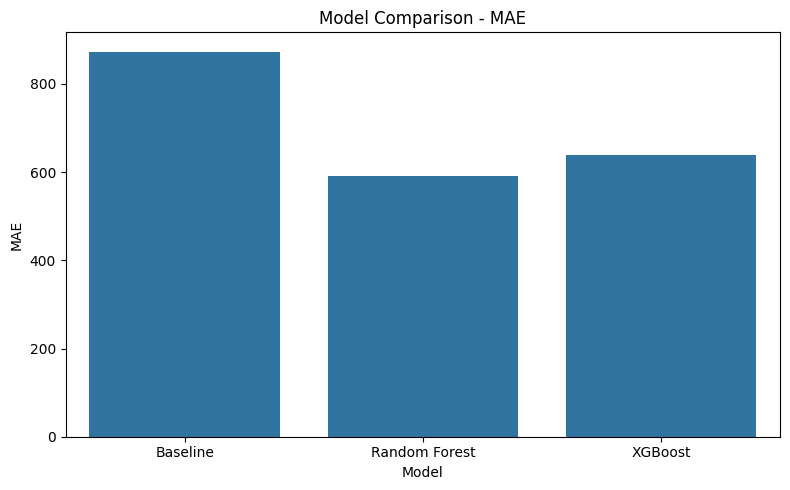

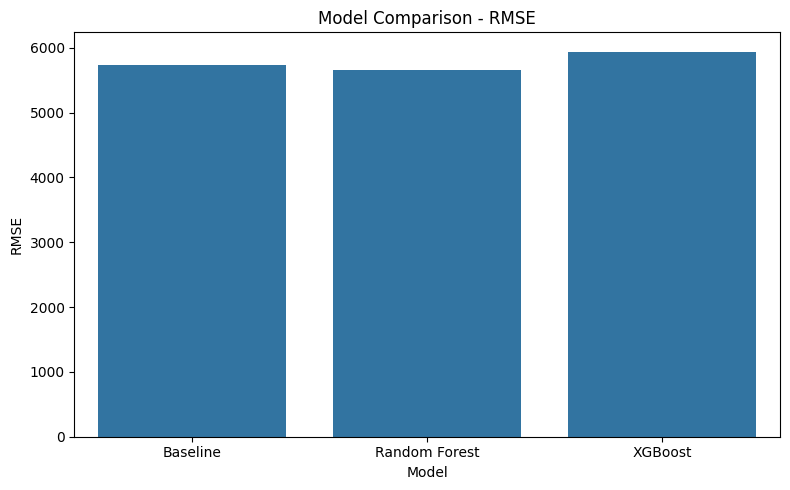

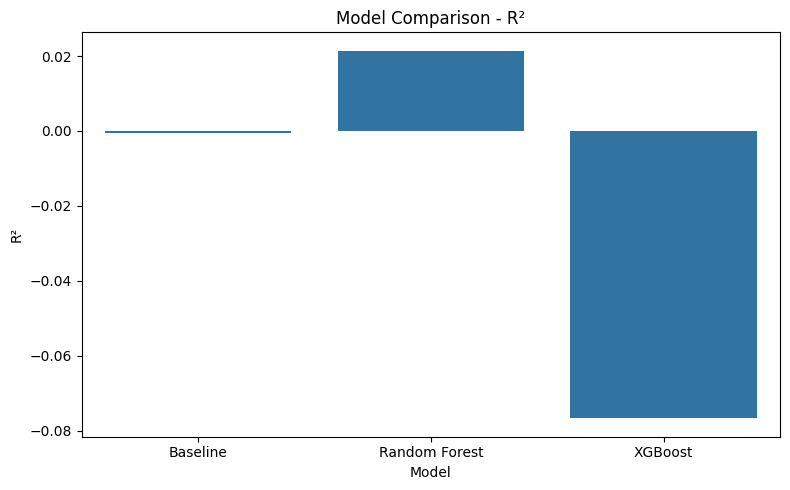

In [35]:
metrics_to_plot = ["MAE", "RMSE", "R²"]
plot_number = 6

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    
    sns.barplot(
        data=model_comparison,
        x="Model",
        y=metric
    )
    
    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.savefig(f"../images/{plot_number:02d}_model_comparison_{metric.lower()}.png")
    plot_number = plot_number + 1
    plt.show()

### 9.1 Actual vs Predicted CLV

The actual and predicted future customer values are compared for the Random Forest model.

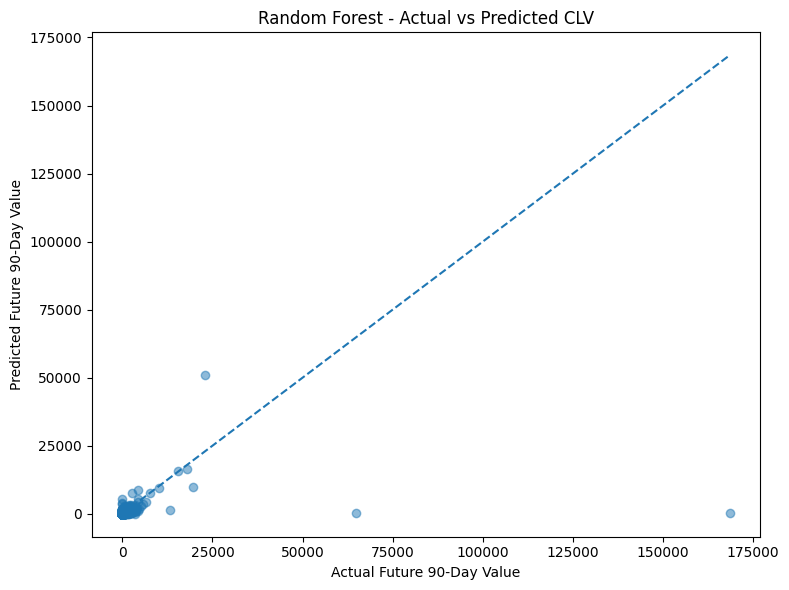

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.5
)

max_value = max(
    y_test.max(),
    random_forest_predictions.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Future 90-Day Value")
plt.ylabel("Predicted Future 90-Day Value")
plt.title("Random Forest - Actual vs Predicted CLV")

plt.tight_layout()
plt.savefig("../images/09_random_forest_actual_vs_predicted.png")
plt.show()

## 10. Random Forest Feature Importance

Feature importance is used to identify which historical customer features contributed most to the Random Forest predictions.

Higher importance indicates that the feature was more useful to the trained model when making predictions.

In [37]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Monetary,0.767119
6,AvgOrderValue,0.110950
8,ProductDiversity,0.030643
7,PurchaseFrequency,0.021840
0,Recency,0.021244
4,Frequency,0.019632
3,active_days,0.011537
1,Tenure_days,0.008825
2,Tenure_months,0.008209


In [38]:
feature_importance.round(4)

,Feature,Importance
5,Monetary,0.7671
6,AvgOrderValue,0.1110
8,ProductDiversity,0.0306
7,PurchaseFrequency,0.0218
0,Recency,0.0212
4,Frequency,0.0196
3,active_days,0.0115
1,Tenure_days,0.0088
2,Tenure_months,0.0082


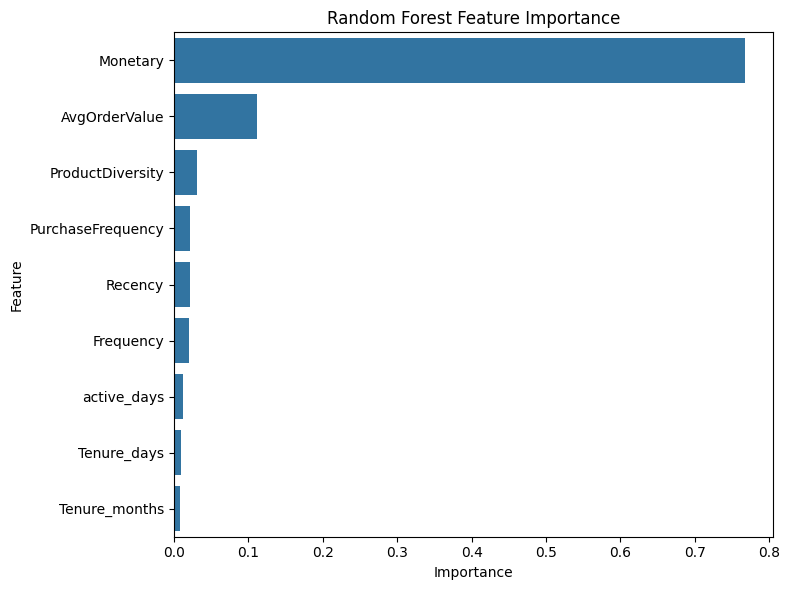

In [39]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../images/10_random_forest_feature_importance.png")
plt.show()

## 11. Final Model Evaluation

The three regression models were evaluated on the same test set using MAE, RMSE, and R².

Random Forest achieved the best performance across all three metrics and is therefore selected as the best-performing model for this project.

However, the relatively low R² indicates that the model explains only a small portion of the variation in future customer value.

### Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Baseline | 873.34 | 5725.76 | -0.0006 |
| Random Forest | 592.08 | 5662.33 | 0.0214 |
| XGBoost | 638.70 | 5939.51 | -0.0767 |

Random Forest performed best across all three evaluation metrics.

The Random Forest feature importance analysis also showed that `Monetary` was the most important historical feature, followed by `AvgOrderValue`.